In [1]:
%pip install pandas numpy scikit-learn matplotlib joblib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import sys
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

In [3]:
# Load analysis input files

df_test_pred = pd.read_csv("/kaggle/input/datasets/thuhiuhong/model-analysis/test_predictions_improved_pse (1).csv")

meta_train = pd.read_csv("/kaggle/input/datasets/thuhiuhong/model-analysis/meta_train (1).csv")
meta_val = pd.read_csv("/kaggle/input/datasets/thuhiuhong/model-analysis/meta_val (1).csv")
meta_test = pd.read_csv("/kaggle/input/datasets/thuhiuhong/model-analysis/meta_test (1).csv")

print("df_test_pred:", df_test_pred.shape)
print("meta_train  :", meta_train.shape)
print("meta_val    :", meta_val.shape)
print("meta_test   :", meta_test.shape)

display(df_test_pred.head())
display(meta_test.head())

df_test_pred: (238447, 7)
meta_train  : (145772, 26)
meta_val    : (190797, 26)
meta_test   : (238447, 26)


,row_id,patient_id,y_true,y_prob,y_pred,member_prob_std,error_type
0,0,1,0,0.166434,0,0.078553,TN
1,1,1,0,0.819948,1,0.038754,FP
2,2,1,0,0.778312,1,0.034036,FP
3,3,1,0,0.654701,1,0.066612,FP
4,4,1,0,0.450869,1,0.103501,FP


,row_id,patient_id,seq_index_within_patient,window_start_pos,window_end_pos,window_start_hour,window_end_hour,y_true,is_sepsis_patient,onset_hour,hours_to_onset,raw_missing_rate_window,last_HR_raw,last_Resp_raw,last_SBP_raw,last_MAP_raw,last_O2Sat_raw,last_Temp_raw,delta_HR_raw,delta_Resp_raw,delta_SBP_raw,delta_MAP_raw,n_obs_HR_window,n_obs_Resp_window,n_obs_SBP_window,n_obs_MAP_window
0,0,1,0,0,9,0,9,0,0,NaN,NaN,0.200000,58.0,11.0,143.0,77.0,95.0,36.11,-3.0,-6.5,19.0,12.0,9,9,9,9
1,1,1,1,1,10,1,10,0,0,NaN,NaN,0.116667,60.0,13.0,153.0,83.0,95.0,NaN,-1.0,-4.5,29.0,18.0,10,10,10,10
2,2,1,2,2,11,2,11,0,0,NaN,NaN,0.133333,60.0,12.0,140.0,74.0,94.0,NaN,-4.0,-15.0,15.0,10.0,10,10,10,10
3,3,1,3,3,12,3,12,0,0,NaN,NaN,0.133333,62.0,12.0,139.0,72.0,95.0,NaN,6.0,3.0,16.0,7.0,10,10,10,10
4,4,1,4,4,13,4,13,0,0,NaN,NaN,0.133333,63.0,11.0,143.0,75.0,95.0,NaN,-3.0,-12.0,23.0,8.0,10,10,10,10


In [4]:
# Validate required prediction columns

required_pred_cols = [
    "row_id",
    "patient_id",
    "y_true",
    "y_prob",
    "y_pred",
    "member_prob_std",
    "error_type",
]

required_meta_cols = [
    "row_id",
    "patient_id",
    "y_true",
    "is_sepsis_patient",
    "onset_hour",
    "hours_to_onset",
    "raw_missing_rate_window",
    "last_HR_raw",
    "last_Resp_raw",
    "last_SBP_raw",
    "last_MAP_raw",
    "delta_HR_raw",
    "delta_Resp_raw",
    "delta_SBP_raw",
    "delta_MAP_raw",
    "window_start_hour",
    "window_end_hour",
]

missing_pred_cols = [col for col in required_pred_cols if col not in df_test_pred.columns]
missing_meta_cols = [col for col in required_meta_cols if col not in meta_test.columns]

assert len(missing_pred_cols) == 0, f"Missing prediction columns: {missing_pred_cols}"
assert len(missing_meta_cols) == 0, f"Missing metadata columns: {missing_meta_cols}"

assert df_test_pred["row_id"].is_unique, "row_id must be unique in df_test_pred"
assert meta_test["row_id"].is_unique, "row_id must be unique in meta_test"

print("Required columns are available.")

Required columns are available.


### MERGE PREDICTIONS WITH METADATA

In [5]:
# Merge test predictions with test metadata

df_test_analysis = df_test_pred.merge(
    meta_test,
    on="row_id",
    how="left",
    validate="one_to_one",
    suffixes=("_pred", "_meta")
)

assert len(df_test_analysis) == len(df_test_pred), "Merged test table has unexpected number of rows"
assert df_test_analysis["patient_id_meta"].notna().all(), "Some prediction rows did not match meta_test"

assert (
    df_test_analysis["patient_id_pred"].values == df_test_analysis["patient_id_meta"].values
).all(), "patient_id mismatch after merge"

assert (
    df_test_analysis["y_true_pred"].values == df_test_analysis["y_true_meta"].values
).all(), "y_true mismatch after merge"

# Keep clean column names for downstream analysis
df_test_analysis["patient_id"] = df_test_analysis["patient_id_pred"]
df_test_analysis["y_true"] = df_test_analysis["y_true_pred"]

df_test_analysis = df_test_analysis.drop(
    columns=[
        "patient_id_pred",
        "patient_id_meta",
        "y_true_pred",
        "y_true_meta",
    ]
)

print("Merged test analysis table:", df_test_analysis.shape)
display(df_test_analysis.head())

Merged test analysis table: (238447, 30)


,row_id,y_prob,y_pred,member_prob_std,error_type,seq_index_within_patient,window_start_pos,window_end_pos,window_start_hour,window_end_hour,is_sepsis_patient,onset_hour,hours_to_onset,raw_missing_rate_window,last_HR_raw,last_Resp_raw,last_SBP_raw,last_MAP_raw,last_O2Sat_raw,last_Temp_raw,delta_HR_raw,delta_Resp_raw,delta_SBP_raw,delta_MAP_raw,n_obs_HR_window,n_obs_Resp_window,n_obs_SBP_window,n_obs_MAP_window,patient_id,y_true
0,0,0.166434,0,0.078553,TN,0,0,9,0,9,0,NaN,NaN,0.200000,58.0,11.0,143.0,77.0,95.0,36.11,-3.0,-6.5,19.0,12.0,9,9,9,9,1,0
1,1,0.819948,1,0.038754,FP,1,1,10,1,10,0,NaN,NaN,0.116667,60.0,13.0,153.0,83.0,95.0,NaN,-1.0,-4.5,29.0,18.0,10,10,10,10,1,0
2,2,0.778312,1,0.034036,FP,2,2,11,2,11,0,NaN,NaN,0.133333,60.0,12.0,140.0,74.0,94.0,NaN,-4.0,-15.0,15.0,10.0,10,10,10,10,1,0
3,3,0.654701,1,0.066612,FP,3,3,12,3,12,0,NaN,NaN,0.133333,62.0,12.0,139.0,72.0,95.0,NaN,6.0,3.0,16.0,7.0,10,10,10,10,1,0
4,4,0.450869,1,0.103501,FP,4,4,13,4,13,0,NaN,NaN,0.133333,63.0,11.0,143.0,75.0,95.0,NaN,-3.0,-12.0,23.0,8.0,10,10,10,10,1,0


In [6]:
# Recompute error_type to verify consistency with y_true and y_pred

recomputed_error_type = np.select(
    [
        (df_test_analysis["y_true"] == 1) & (df_test_analysis["y_pred"] == 1),
        (df_test_analysis["y_true"] == 1) & (df_test_analysis["y_pred"] == 0),
        (df_test_analysis["y_true"] == 0) & (df_test_analysis["y_pred"] == 1),
    ],
    ["TP", "FN", "FP"],
    default="TN"
)

assert (
    df_test_analysis["error_type"].values == recomputed_error_type
).all(), "error_type is inconsistent with y_true and y_pred"

print("error_type is consistent with y_true and y_pred.")
print(df_test_analysis["error_type"].value_counts())

error_type is consistent with y_true and y_pred.
error_type
TN    166183
FP     68113
TP      3451
FN       700
Name: count, dtype: int64


### FINAL TEST METRIC CHECK

In [7]:
def compute_binary_metrics(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    youden_j = sensitivity + specificity - 1

    if len(np.unique(y_true)) < 2:
        auroc = np.nan
        auprc = np.nan
    else:
        auroc = roc_auc_score(y_true, y_prob)
        auprc = average_precision_score(y_true, y_prob)

    return {
        "AUROC": auroc,
        "AUPRC": auprc,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "Youden's J": youden_j,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    }

test_metrics = compute_binary_metrics(
    y_true=df_test_analysis["y_true"],
    y_pred=df_test_analysis["y_pred"],
    y_prob=df_test_analysis["y_prob"],
)

df_test_metrics = pd.DataFrame([test_metrics])

display(df_test_metrics)


,AUROC,AUPRC,Accuracy,Sensitivity,Specificity,Precision,Recall,F1-score,Youden's J,TN,FP,FN,TP
0,0.848246,0.116237,0.711412,0.831366,0.709287,0.048223,0.831366,0.091158,0.540652,166183,68113,700,3451


### CREATE CLINICAL SUBGROUP FLAGS

In [8]:
# Fixed missingness cutoff from the training set

missing_cutoff = meta_train["raw_missing_rate_window"].median()

print("missing_cutoff from train =", missing_cutoff)

missing_cutoff from train = 0.1666666666666666


In [9]:
# Create clinically meaningful subgroup flags

df_test_analysis["hr_high"] = (df_test_analysis["last_HR_raw"] >= 100).astype(int)
df_test_analysis["resp_high"] = (df_test_analysis["last_Resp_raw"] >= 22).astype(int)
df_test_analysis["sbp_low"] = (df_test_analysis["last_SBP_raw"] <= 100).astype(int)
df_test_analysis["map_low"] = (df_test_analysis["last_MAP_raw"] < 65).astype(int)

df_test_analysis["missing_high"] = (
    df_test_analysis["raw_missing_rate_window"] >= missing_cutoff
).astype(int)

df_test_analysis["delta_hr_up"] = (df_test_analysis["delta_HR_raw"] > 0).astype(int)
df_test_analysis["delta_resp_up"] = (df_test_analysis["delta_Resp_raw"] > 0).astype(int)
df_test_analysis["delta_sbp_down"] = (df_test_analysis["delta_SBP_raw"] < 0).astype(int)
df_test_analysis["delta_map_down"] = (df_test_analysis["delta_MAP_raw"] < 0).astype(int)

df_test_analysis["eda_pattern_strong"] = (
    (df_test_analysis["delta_hr_up"] == 1) &
    (df_test_analysis["delta_resp_up"] == 1) &
    (
        (df_test_analysis["delta_sbp_down"] == 1) |
        (df_test_analysis["delta_map_down"] == 1)
    )
).astype(int)

df_test_analysis["physiologic_instability"] = (
    (df_test_analysis["hr_high"] == 1) |
    (df_test_analysis["resp_high"] == 1) |
    (df_test_analysis["sbp_low"] == 1) |
    (df_test_analysis["map_low"] == 1)
).astype(int)

df_test_analysis["near_onset_6h"] = (
    (df_test_analysis["is_sepsis_patient"] == 1) &
    (df_test_analysis["hours_to_onset"] >= 0) &
    (df_test_analysis["hours_to_onset"] <= 6)
).astype(int)

subgroups = [
    "hr_high",
    "resp_high",
    "sbp_low",
    "map_low",
    "missing_high",
    "eda_pattern_strong",
    "physiologic_instability",
    "near_onset_6h",
]

print("Done creating subgroup flags.")
print("Subgroup positive counts:")
display(df_test_analysis[subgroups].sum().to_frame("n_positive_flag"))

Done creating subgroup flags.
Subgroup positive counts:


,n_positive_flag
hr_high,40179
resp_high,52498
sbp_low,30975
map_low,23400
missing_high,112889
eda_pattern_strong,28300
physiologic_instability,104277
near_onset_6h,2574


### ERROR GROUP SUMMARY

In [10]:
def summarize_error_groups(df):
    return (
        df.groupby("error_type")
        .agg(
            n=("row_id", "size"),
            n_patients=("patient_id", "nunique"),
            mean_prob=("y_prob", "mean"),
            median_prob=("y_prob", "median"),
            mean_member_std=("member_prob_std", "mean"),
            positive_rate=("y_true", "mean"),
            mean_hr_high=("hr_high", "mean"),
            mean_resp_high=("resp_high", "mean"),
            mean_sbp_low=("sbp_low", "mean"),
            mean_map_low=("map_low", "mean"),
            mean_missing_high=("missing_high", "mean"),
            mean_eda_pattern_strong=("eda_pattern_strong", "mean"),
        )
        .reset_index()
        .sort_values("n", ascending=False)
    )

df_error_summary = summarize_error_groups(df_test_analysis)

display(df_error_summary)

error_summary_path = ("/kaggle/working/analysis_error_group_summary.csv")
df_error_summary.to_csv(error_summary_path, index=False)

print("Saved:", error_summary_path)

,error_type,n,n_patients,mean_prob,median_prob,mean_member_std,positive_rate,mean_hr_high,mean_resp_high,mean_sbp_low,mean_map_low,mean_missing_high,mean_eda_pattern_strong
2,TN,166183,7752,0.141472,0.101907,0.077279,0.0,0.138913,0.189201,0.110794,0.080887,0.490201,0.116312
1,FP,68113,6243,0.668141,0.659246,0.100757,0.0,0.234126,0.287669,0.174299,0.138138,0.433177,0.123104
3,TP,3451,450,0.776869,0.823918,0.065243,1.0,0.286873,0.373225,0.171544,0.139670,0.454361,0.138800
0,FN,700,182,0.243391,0.260008,0.113435,1.0,0.224286,0.248571,0.141429,0.095714,0.504286,0.152857


Saved: /kaggle/working/analysis_error_group_summary.csv


### SUBGROUP PERFORMANCE

In [11]:
def subgroup_report(df, group_col):
    rows = []

    for group_value, sub in df.groupby(group_col):
        y_true = sub["y_true"].values
        y_pred = sub["y_pred"].values
        y_prob = sub["y_prob"].values

        metrics = compute_binary_metrics(y_true, y_pred, y_prob)

        rows.append({
            "subgroup": group_col,
            "value": int(group_value),
            "n": len(sub),
            "n_patients": sub["patient_id"].nunique(),
            "positive_rate": sub["y_true"].mean(),
            "mean_y_prob": sub["y_prob"].mean(),
            "median_y_prob": sub["y_prob"].median(),
            "mean_member_std": sub["member_prob_std"].mean(),
            **metrics,
        })

    return pd.DataFrame(rows).sort_values(["subgroup", "value"])

df_subgroup_table = pd.concat(
    [subgroup_report(df_test_analysis, sg) for sg in subgroups],
    ignore_index=True
)

display(df_subgroup_table)

subgroup_path = "/kaggle/working/subgroup_performance_table.csv"
df_subgroup_table.to_csv(subgroup_path, index=False)

print("Saved:", subgroup_path)

,subgroup,value,n,n_patients,positive_rate,mean_y_prob,median_y_prob,mean_member_std,AUROC,AUPRC,Accuracy,Sensitivity,Specificity,Precision,Recall,F1-score,Youden's J,TN,FP,FN,TP
0,hr_high,0,198268,7854,0.015151,0.283002,0.175562,0.081800,0.852351,0.106452,0.734153,0.819241,0.732844,0.045051,0.819241,0.085405,0.552085,143098,52166,543,2461
1,hr_high,1,40179,3566,0.028547,0.392253,0.341753,0.094367,0.815819,0.142387,0.599194,0.863121,0.591438,0.058452,0.863121,0.109489,0.454559,23085,15947,157,990
2,resp_high,0,185949,7908,0.014461,0.280455,0.174840,0.082719,0.845450,0.107645,0.736245,0.804388,0.735245,0.042678,0.804388,0.081055,0.539633,134741,48519,526,2163
3,resp_high,1,52498,5898,0.027849,0.375639,0.304843,0.088163,0.835517,0.133154,0.623452,0.880985,0.616075,0.061680,0.880985,0.115288,0.497060,31442,19594,174,1288
4,sbp_low,0,207472,7940,0.016677,0.290079,0.183212,0.081480,0.853288,0.112161,0.726026,0.826301,0.724325,0.048376,0.826301,0.091400,0.550626,147771,56241,601,2859
5,sbp_low,1,30975,4314,0.022308,0.377314,0.321426,0.100244,0.813656,0.135898,0.613527,0.856729,0.607978,0.047497,0.856729,0.090004,0.464707,18412,11872,99,592
6,map_low,0,215047,7944,0.016750,0.291560,0.184392,0.082198,0.849589,0.109817,0.724074,0.824264,0.722368,0.048141,0.824264,0.090969,0.546632,152741,58704,633,2969
7,map_low,1,23400,3787,0.023462,0.391945,0.347085,0.099723,0.831747,0.160085,0.595043,0.877960,0.588246,0.048731,0.877960,0.092337,0.466206,13442,9409,67,482
8,missing_high,0,125558,6716,0.017761,0.319893,0.228022,0.087438,0.849549,0.115061,0.689745,0.844395,0.686949,0.046504,0.844395,0.088153,0.531343,84720,38608,347,1883
9,missing_high,1,112889,7102,0.017017,0.280855,0.168398,0.080002,0.847192,0.119832,0.735510,0.816242,0.734113,0.050462,0.816242,0.095048,0.550354,81463,29505,353,1568


Saved: /kaggle/working/subgroup_performance_table.csv


### SUBGROUP PROBABILITY SHIFT FIGURE

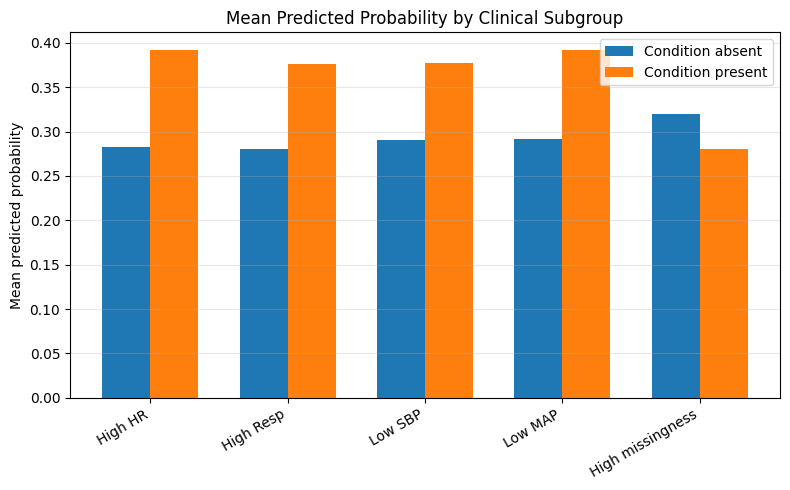

Saved: /kaggle/working/figure_subgroup_probability_shift_main_model.png


In [12]:
# Plot mean predicted probability by subgroup status
# Thesis-friendly version

import numpy as np
import matplotlib.pyplot as plt

subgroup_order = [
    "hr_high",
    "resp_high",
    "sbp_low",
    "map_low",
    "missing_high",
]

subgroup_labels = {
    "hr_high": "High HR",
    "resp_high": "High Resp",
    "sbp_low": "Low SBP",
    "map_low": "Low MAP",
    "missing_high": "High missingness",
}

plot_df = df_subgroup_table[
    df_subgroup_table["subgroup"].isin(subgroup_order)
].copy()

plot_df["label"] = plot_df["subgroup"].map(subgroup_labels)

pivot_plot = plot_df.pivot(
    index="label",
    columns="value",
    values="mean_y_prob"
)

# Keep fixed order for thesis figure
pivot_plot = pivot_plot.loc[
    [subgroup_labels[s] for s in subgroup_order]
]

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(pivot_plot.index))
width = 0.35

ax.bar(
    x - width / 2,
    pivot_plot[0],
    width,
    label="Condition absent"
)

ax.bar(
    x + width / 2,
    pivot_plot[1],
    width,
    label="Condition present"
)

ax.set_xticks(x)
ax.set_xticklabels(pivot_plot.index, rotation=30, ha="right")
ax.set_ylabel("Mean predicted probability")
ax.set_title("Mean Predicted Probability by Clinical Subgroup")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="best")

plt.tight_layout()

fig_path = "/kaggle/working/figure_subgroup_probability_shift_main_model.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

### MISSINGNESS ERROR PATTERN

In [13]:
rows = []

for value in [0, 1]:
    sub = df_test_analysis[df_test_analysis["missing_high"] == value].copy()

    pos = sub[sub["y_true"] == 1]
    neg = sub[sub["y_true"] == 0]

    fn = ((pos["y_pred"] == 0).sum()) if len(pos) > 0 else 0
    tp = ((pos["y_pred"] == 1).sum()) if len(pos) > 0 else 0
    fp = ((neg["y_pred"] == 1).sum()) if len(neg) > 0 else 0
    tn = ((neg["y_pred"] == 0).sum()) if len(neg) > 0 else 0

    rows.append({
        "missing_high": value,
        "n": len(sub),
        "n_patients": sub["patient_id"].nunique(),
        "n_positive": len(pos),
        "n_negative": len(neg),
        "FN": fn,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN_rate_within_positive": fn / len(pos) if len(pos) > 0 else np.nan,
        "TP_rate_within_positive": tp / len(pos) if len(pos) > 0 else np.nan,
        "FP_rate_within_negative": fp / len(neg) if len(neg) > 0 else np.nan,
        "TN_rate_within_negative": tn / len(neg) if len(neg) > 0 else np.nan,
        "mean_y_prob": sub["y_prob"].mean(),
        "mean_member_std": sub["member_prob_std"].mean(),
    })

df_missing_table = pd.DataFrame(rows)

display(df_missing_table)

missing_path = "/kaggle/working/missingness_error_table.csv"
df_missing_table.to_csv(missing_path, index=False)

print("Saved:", missing_path)

,missing_high,n,n_patients,n_positive,n_negative,FN,TP,FP,TN,FN_rate_within_positive,TP_rate_within_positive,FP_rate_within_negative,TN_rate_within_negative,mean_y_prob,mean_member_std
0,0,125558,6716,2230,123328,347,1883,38608,84720,0.155605,0.844395,0.313051,0.686949,0.319893,0.087438
1,1,112889,7102,1921,110968,353,1568,29505,81463,0.183758,0.816242,0.265887,0.734113,0.280855,0.080002


Saved: /kaggle/working/missingness_error_table.csv


### FN AND FP REPORTS BY SUBGROUP

In [14]:
def fn_report(df, group_col):
    rows = []

    for group_value, sub in df.groupby(group_col):
        pos = sub[sub["y_true"] == 1].copy()
        n_pos = len(pos)

        fn = (pos["error_type"] == "FN").sum()
        tp = (pos["error_type"] == "TP").sum()

        fn_sub = pos[pos["error_type"] == "FN"]

        rows.append({
            "subgroup": group_col,
            "value": int(group_value),
            "n_total": len(sub),
            "n_positive": n_pos,
            "FN": fn,
            "TP": tp,
            "FN_rate_within_positive": fn / n_pos if n_pos > 0 else np.nan,
            "TP_rate_within_positive": tp / n_pos if n_pos > 0 else np.nan,
            "mean_prob_positive": pos["y_prob"].mean() if n_pos > 0 else np.nan,
            "mean_prob_FN": fn_sub["y_prob"].mean() if len(fn_sub) > 0 else np.nan,
            "mean_member_std_FN": fn_sub["member_prob_std"].mean() if len(fn_sub) > 0 else np.nan,
        })

    return pd.DataFrame(rows).sort_values(["subgroup", "value"])

def fp_report(df, group_col):
    rows = []

    for group_value, sub in df.groupby(group_col):
        neg = sub[sub["y_true"] == 0].copy()
        n_neg = len(neg)

        fp = (neg["error_type"] == "FP").sum()
        tn = (neg["error_type"] == "TN").sum()

        fp_sub = neg[neg["error_type"] == "FP"]

        rows.append({
            "subgroup": group_col,
            "value": int(group_value),
            "n_total": len(sub),
            "n_negative": n_neg,
            "FP": fp,
            "TN": tn,
            "FP_rate_within_negative": fp / n_neg if n_neg > 0 else np.nan,
            "TN_rate_within_negative": tn / n_neg if n_neg > 0 else np.nan,
            "mean_prob_negative": neg["y_prob"].mean() if n_neg > 0 else np.nan,
            "mean_prob_FP": fp_sub["y_prob"].mean() if len(fp_sub) > 0 else np.nan,
            "mean_member_std_FP": fp_sub["member_prob_std"].mean() if len(fp_sub) > 0 else np.nan,
        })

    return pd.DataFrame(rows).sort_values(["subgroup", "value"])

df_fn_by_subgroup = pd.concat(
    [fn_report(df_test_analysis, sg) for sg in subgroups],
    ignore_index=True
)

df_fp_by_subgroup = pd.concat(
    [fp_report(df_test_analysis, sg) for sg in subgroups],
    ignore_index=True
)

display(df_fn_by_subgroup)
display(df_fp_by_subgroup)

fn_path = "/kaggle/working/fn_by_subgroup_table.csv"
fp_path = "/kaggle/working/fp_by_subgroup_table.csv"

df_fn_by_subgroup.to_csv(fn_path, index=False)
df_fp_by_subgroup.to_csv(fp_path, index=False)

print("Saved:", fn_path)
print("Saved:", fp_path)

,subgroup,value,n_total,n_positive,FN,TP,FN_rate_within_positive,TP_rate_within_positive,mean_prob_positive,mean_prob_FN,mean_member_std_FN
0,hr_high,0,198268,3004,543,2461,0.180759,0.819241,0.675109,0.240251,0.110304
1,hr_high,1,40179,1147,157,990,0.136879,0.863121,0.717804,0.254253,0.124263
2,resp_high,0,185949,2689,526,2163,0.195612,0.804388,0.661527,0.235133,0.112655
3,resp_high,1,52498,1462,174,1288,0.119015,0.880985,0.733587,0.268357,0.115793
4,sbp_low,0,207472,3460,601,2859,0.173699,0.826301,0.683873,0.244437,0.113152
5,sbp_low,1,30975,691,99,592,0.143271,0.856729,0.702098,0.237040,0.115156
6,map_low,0,215047,3602,633,2969,0.175736,0.824264,0.681111,0.240043,0.113704
7,map_low,1,23400,549,67,482,0.122040,0.877960,0.724933,0.275022,0.110889
8,missing_high,0,125558,2230,347,1883,0.155605,0.844395,0.700096,0.263153,0.120562
9,missing_high,1,112889,1921,353,1568,0.183758,0.816242,0.671596,0.223965,0.106430


,subgroup,value,n_total,n_negative,FP,TN,FP_rate_within_negative,TN_rate_within_negative,mean_prob_negative,mean_prob_FP,mean_member_std_FP
0,hr_high,0,198268,195264,52166,143098,0.267156,0.732844,0.276970,0.663818,0.101260
1,hr_high,1,40179,39032,15947,23085,0.408562,0.591438,0.382686,0.682279,0.099112
2,resp_high,0,185949,183260,48519,134741,0.264755,0.735245,0.274863,0.659292,0.103425
3,resp_high,1,52498,51036,19594,31442,0.383925,0.616075,0.365385,0.690052,0.094151
4,sbp_low,0,207472,204012,56241,147771,0.275675,0.724325,0.283400,0.666903,0.099580
5,sbp_low,1,30975,30284,11872,18412,0.392022,0.607978,0.369904,0.674005,0.106335
6,map_low,0,215047,211445,58704,152741,0.277632,0.722368,0.284924,0.668281,0.100025
7,map_low,1,23400,22851,9409,13442,0.411754,0.588246,0.383945,0.667266,0.105323
8,missing_high,0,125558,123328,38608,84720,0.313051,0.686949,0.313018,0.668929,0.099095
9,missing_high,1,112889,110968,29505,81463,0.265887,0.734113,0.274091,0.667109,0.102932


Saved: /kaggle/working/fn_by_subgroup_table.csv
Saved: /kaggle/working/fp_by_subgroup_table.csv


### CASE STUDIES OF THE MAIN MODEL AT THE WINDOW LEVEL

In [15]:
case_columns = [
    "patient_id",
    "row_id",
    "error_type",
    "y_true",
    "y_pred",
    "y_prob",
    "member_prob_std",
    "window_start_hour",
    "window_end_hour",
    "onset_hour",
    "hours_to_onset",
    "raw_missing_rate_window",
    "last_HR_raw",
    "last_Resp_raw",
    "last_SBP_raw",
    "last_MAP_raw",
    "hr_high",
    "resp_high",
    "sbp_low",
    "map_low",
    "missing_high",
    "eda_pattern_strong",
]

def select_first_available_case(df, filters, sort_cols, ascending):
    candidates = df.copy()

    for condition in filters:
        candidates = candidates[condition(candidates)].copy()

    if len(candidates) == 0:
        return None

    candidates = candidates.sort_values(sort_cols, ascending=ascending)
    return candidates.iloc[0]

tp_case = select_first_available_case(
    df_test_analysis,
    filters=[
        lambda d: d["error_type"] == "TP",
        lambda d: d["is_sepsis_patient"] == 1,
        lambda d: d["hours_to_onset"].between(0, 6),
        lambda d: d["physiologic_instability"] == 1,
    ],
    sort_cols=["y_prob", "member_prob_std"],
    ascending=[False, True],
)

fn_case = select_first_available_case(
    df_test_analysis,
    filters=[
        lambda d: d["error_type"] == "FN",
        lambda d: d["is_sepsis_patient"] == 1,
        lambda d: d["hours_to_onset"].between(0, 6),
    ],
    sort_cols=["missing_high", "eda_pattern_strong", "y_prob", "member_prob_std"],
    ascending=[False, False, False, True],
)

fp_case = select_first_available_case(
    df_test_analysis,
    filters=[
        lambda d: d["error_type"] == "FP",
        lambda d: d["is_sepsis_patient"] == 0,
        lambda d: d["physiologic_instability"] == 1,
    ],
    sort_cols=["y_prob", "member_prob_std"],
    ascending=[False, True],
)

# Fallback selection if strict filters return no candidates
if tp_case is None:
    tp_case = df_test_analysis[df_test_analysis["error_type"] == "TP"].sort_values(
        ["y_prob", "member_prob_std"],
        ascending=[False, True],
    ).iloc[0]

if fn_case is None:
    fn_case = df_test_analysis[df_test_analysis["error_type"] == "FN"].sort_values(
        ["y_prob", "member_prob_std"],
        ascending=[False, True],
    ).iloc[0]

if fp_case is None:
    fp_case = df_test_analysis[df_test_analysis["error_type"] == "FP"].sort_values(
        ["y_prob", "member_prob_std"],
        ascending=[False, True],
    ).iloc[0]

selected_cases = pd.DataFrame([
    tp_case,
    fn_case,
    fp_case,
]).copy()

selected_cases.index = ["TP_case", "FN_case", "FP_case"]

display(selected_cases[case_columns])

case_path = "/kaggle/working/case_study_windows_table.csv"
selected_cases[case_columns].to_csv(case_path)

print("Saved:", case_path)

,patient_id,row_id,error_type,y_true,y_pred,y_prob,member_prob_std,window_start_hour,window_end_hour,onset_hour,hours_to_onset,raw_missing_rate_window,last_HR_raw,last_Resp_raw,last_SBP_raw,last_MAP_raw,hr_high,resp_high,sbp_low,map_low,missing_high,eda_pattern_strong
TP_case,14528,86062,TP,1,1,0.938941,0.026185,1,10,10.0,0.0,0.283333,110.0,16.0,112.0,71.00,1,0,0,0,1,0
FN_case,18012,104798,FN,1,0,0.331702,0.237816,0,9,9.0,0.0,0.333333,96.0,27.0,122.0,87.17,0,1,0,0,1,1
FP_case,32932,194891,FP,0,1,0.955666,0.015772,24,33,NaN,NaN,0.416667,110.0,NaN,90.0,67.00,1,0,1,0,1,0


Saved: /kaggle/working/case_study_windows_table.csv


### CASE-LEVEL PROBABILITY TRAJECTORIES

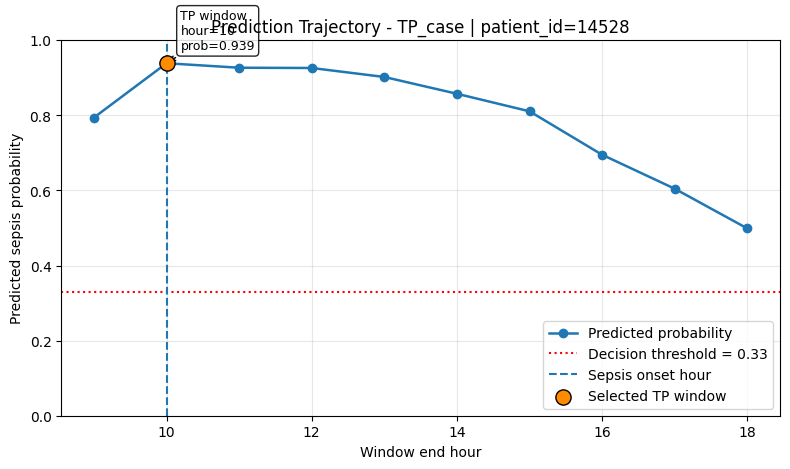

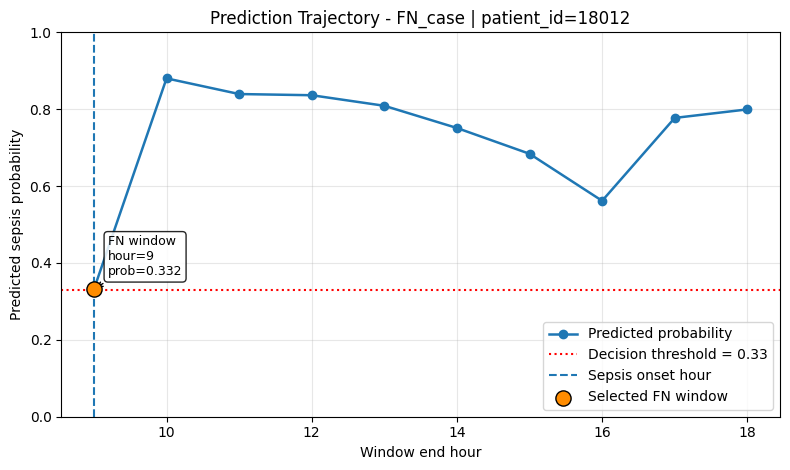

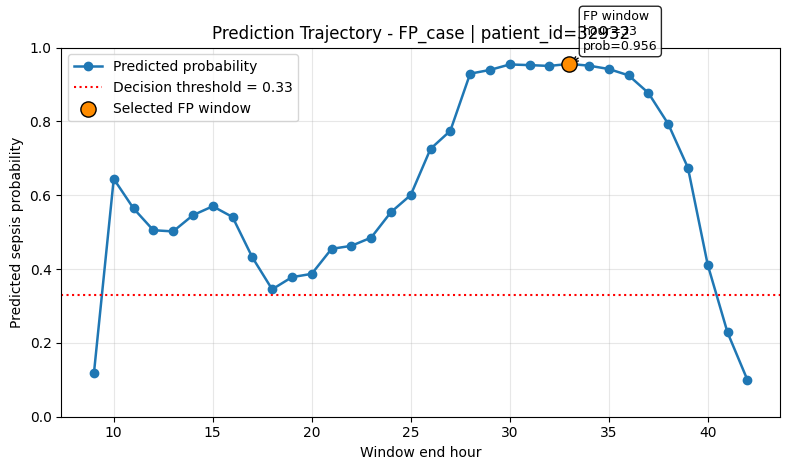

In [16]:
# Plot prediction trajectories for the selected case-study patients

DECISION_THRESHOLD = 0.33

for case_name, case_row in selected_cases.iterrows():
    patient_id = case_row["patient_id"]

    patient_df = (
        df_test_analysis[df_test_analysis["patient_id"] == patient_id]
        .sort_values("window_end_hour")
        .copy()
    )

    fig, ax = plt.subplots(figsize=(8, 4.8))

    ax.plot(
        patient_df["window_end_hour"],
        patient_df["y_prob"],
        marker="o",
        linewidth=1.8,
        label="Predicted probability",
    )

    # Decision threshold
    ax.axhline(
        DECISION_THRESHOLD,
        linestyle=":",
        linewidth=1.5,
        color="red",
        label=f"Decision threshold = {DECISION_THRESHOLD:.2f}",
    )

    # Sepsis onset line for sepsis patients
    if pd.notna(case_row["onset_hour"]):
        ax.axvline(
            case_row["onset_hour"],
            linestyle="--",
            linewidth=1.5,
            color="tab:blue",
            label="Sepsis onset hour",
        )

    # Highlight selected case-study window
    ax.scatter(
        [case_row["window_end_hour"]],
        [case_row["y_prob"]],
        s=120,
        color="darkorange",
        edgecolor="black",
        zorder=5,
        label=f"Selected {case_row['error_type']} window",
    )

    # Annotate selected window
    ax.annotate(
        (
            f"{case_row['error_type']} window\n"
            f"hour={case_row['window_end_hour']:.0f}\n"
            f"prob={case_row['y_prob']:.3f}"
        ),
        xy=(case_row["window_end_hour"], case_row["y_prob"]),
        xytext=(10, 10),
        textcoords="offset points",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.85),
        arrowprops=dict(arrowstyle="->", lw=1),
    )

    ax.set_xlabel("Window end hour")
    ax.set_ylabel("Predicted sepsis probability")
    ax.set_title(f"Prediction Trajectory - {case_name} | patient_id={patient_id}")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys(), loc="best")

    plt.tight_layout()
    plt.show()

,Subgroup,Change in FN rate,Change in FP rate
0,High HR,-0.043880,0.141406
1,High Resp,-0.076597,0.119170
2,Low SBP,-0.030429,0.116347
3,Low MAP,-0.053696,0.134122
4,High missingness,0.028153,-0.047164


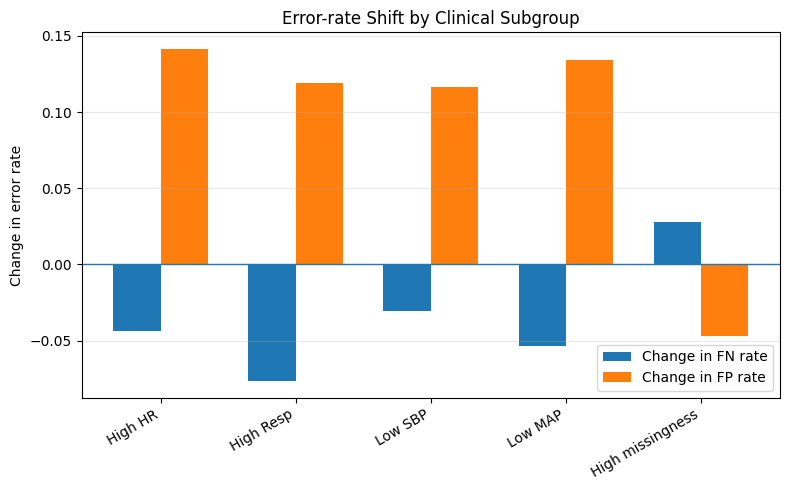

Saved: /kaggle/working/figure_subgroup_error_rate_shift_clean.png


In [17]:
# Clean Figure 4.Y: Error-rate shift by clinical subgroup
# Delta = Yes group - No group
# This figure is intended for visualization only; detailed numeric deltas are not listed in the thesis text.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

subgroup_order = [
    "hr_high",
    "resp_high",
    "sbp_low",
    "map_low",
    "missing_high",
]

subgroup_labels = {
    "hr_high": "High HR",
    "resp_high": "High Resp",
    "sbp_low": "Low SBP",
    "map_low": "Low MAP",
    "missing_high": "High missingness",
}

# Select subgroup rows
error_df = df_subgroup_table[
    df_subgroup_table["subgroup"].isin(subgroup_order)
].copy()

error_df["label"] = error_df["subgroup"].map(subgroup_labels)

# Compute FN rate and FP rate
# Prefer confusion-count columns if available
cols = set(error_df.columns)

if {"TP", "FN", "FP", "TN"}.issubset(cols):
    error_df["fn_rate"] = error_df["FN"] / (error_df["TP"] + error_df["FN"])
    error_df["fp_rate"] = error_df["FP"] / (error_df["FP"] + error_df["TN"])

elif {"tp", "fn", "fp", "tn"}.issubset(cols):
    error_df["fn_rate"] = error_df["fn"] / (error_df["tp"] + error_df["fn"])
    error_df["fp_rate"] = error_df["fp"] / (error_df["fp"] + error_df["tn"])

elif {"sensitivity", "specificity"}.issubset(cols):
    error_df["fn_rate"] = 1 - error_df["sensitivity"]
    error_df["fp_rate"] = 1 - error_df["specificity"]

elif {"sens", "spec"}.issubset(cols):
    error_df["fn_rate"] = 1 - error_df["sens"]
    error_df["fp_rate"] = 1 - error_df["spec"]

else:
    raise ValueError(
        "Cannot compute FN/FP rates. Need TP/FN/FP/TN, tp/fn/fp/tn, "
        "sensitivity/specificity, or sens/spec columns."
    )

# Keep fixed order
error_df["label"] = pd.Categorical(
    error_df["label"],
    categories=[subgroup_labels[s] for s in subgroup_order],
    ordered=True
)

error_df = error_df.sort_values(["label", "value"])

# Pivot to calculate Yes - No
pivot_error = error_df.pivot(
    index="label",
    columns="value",
    values=["fn_rate", "fp_rate"]
)

df_delta = pd.DataFrame(index=pivot_error.index)
df_delta["Change in FN rate"] = pivot_error[("fn_rate", 1)] - pivot_error[("fn_rate", 0)]
df_delta["Change in FP rate"] = pivot_error[("fp_rate", 1)] - pivot_error[("fp_rate", 0)]

df_delta = df_delta.reset_index().rename(columns={"label": "Subgroup"})

display(df_delta)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(df_delta["Subgroup"]))
width = 0.35

ax.bar(
    x - width / 2,
    df_delta["Change in FN rate"],
    width,
    label="Change in FN rate"
)

ax.bar(
    x + width / 2,
    df_delta["Change in FP rate"],
    width,
    label="Change in FP rate"
)

ax.axhline(0, linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(df_delta["Subgroup"], rotation=30, ha="right")
ax.set_ylabel("Change in error rate")
ax.set_title("Error-rate Shift by Clinical Subgroup")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="best")

plt.tight_layout()

fig_path = "/kaggle/working/figure_subgroup_error_rate_shift_clean.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

In [18]:
INPUT_PATH = "/kaggle/input/datasets/thuhiuhong/traintestval-lstm"

y_test = np.load(os.path.join(INPUT_PATH, 'y_test (1).npy'))


Index(['row_id', 'patient_id', 'y_true', 'y_prob', 'y_pred', 'member_prob_std', 'error_type'], dtype='object')
AUPRC = 0.1162
Random baseline = 0.0174
Threshold = 0.43
Recall = 0.8314
Precision = 0.0482
TN=166183, FP=68113, FN=700, TP=3451


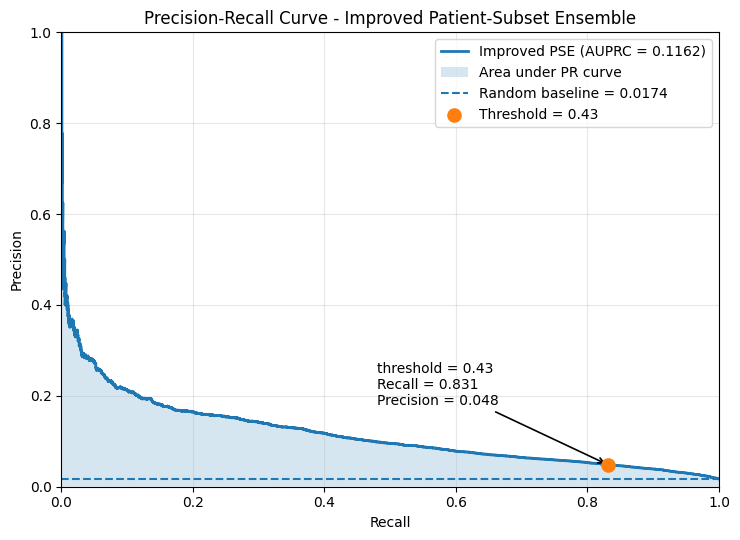

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score, confusion_matrix

# =========================
# 1. Load prediction file
# =========================


print(df_test_pred.columns)

y_true = df_test_pred["y_true"].values
y_prob = df_test_pred["y_prob"].values

# =========================
# 2. Compute PR curve
# =========================
precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
auprc = average_precision_score(y_true, y_prob)

# Random baseline = positive rate
baseline = y_true.mean()

# =========================
# 3. Operating point
# =========================
threshold = 0.43
y_pred = (y_prob >= threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

op_recall = tp / (tp + fn)
op_precision = tp / (tp + fp)

print(f"AUPRC = {auprc:.4f}")
print(f"Random baseline = {baseline:.4f}")
print(f"Threshold = {threshold}")
print(f"Recall = {op_recall:.4f}")
print(f"Precision = {op_precision:.4f}")
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

# =========================
# 4. Sort for fill_between
# =========================
order = np.argsort(recall)
recall_sorted = recall[order]
precision_sorted = precision[order]

# =========================
# 5. Plot PR curve
# =========================
plt.figure(figsize=(7.5, 5.5))

plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"Improved PSE (AUPRC = {auprc:.4f})"
)

plt.fill_between(
    recall_sorted,
    precision_sorted,
    alpha=0.18,
    label="Area under PR curve"
)

plt.axhline(
    y=baseline,
    linestyle="--",
    linewidth=1.5,
    label=f"Random baseline = {baseline:.4f}"
)

plt.scatter(
    op_recall,
    op_precision,
    s=90,
    zorder=5,
    label=f"Threshold = {threshold:.2f}"
)

plt.annotate(
    f"threshold = {threshold:.2f}\nRecall = {op_recall:.3f}\nPrecision = {op_precision:.3f}",
    xy=(op_recall, op_precision),
    xytext=(0.48, 0.18),
    arrowprops=dict(arrowstyle="->", lw=1.2),
    fontsize=10,
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Improved Patient-Subset Ensemble")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend(loc="upper right")
plt.tight_layout()

plt.savefig("pr_curve_improved_pse_annotated.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
# Patient-level and alert-level evaluation
# This section should be run after df_test_analysis has been created by merging predictions with metadata.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

FINAL_THRESHOLD = 0.43

df_patient_eval = df_test_analysis.copy()

# Define model alert using the final threshold.
# Do not rely on y_true here: a pre-onset alert may still have y_true = 0 at the window level,
# but it is clinically important for patient-level early warning analysis.
df_patient_eval["alert"] = (df_patient_eval["y_prob"] >= FINAL_THRESHOLD).astype(int)

# Optional consistency check against stored y_pred.
if "y_pred" in df_patient_eval.columns:
    mismatch_rate = (df_patient_eval["alert"] != df_patient_eval["y_pred"]).mean()
    print(f"Mismatch rate between recomputed alert and stored y_pred: {mismatch_rate:.6f}")
    if mismatch_rate > 0:
        print("Note: downstream patient-level analysis uses recomputed alert from y_prob and FINAL_THRESHOLD.")

# Window-level sanity check: this should match the final confusion matrix.
tn, fp, fn, tp = confusion_matrix(
    df_patient_eval["y_true"],
    df_patient_eval["alert"],
    labels=[0, 1]
).ravel()

print("Window-level check at threshold =", FINAL_THRESHOLD)
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Sensitivity={tp/(tp+fn):.4f}")
print(f"Specificity={tn/(tn+fp):.4f}")
print(f"Precision={tp/(tp+fp):.4f}")

def get_episode_ranges(alert_hours):
    """Return consecutive alert episodes from a sorted list/array of alert hours."""
    if len(alert_hours) == 0:
        return []

    hours = np.sort(np.asarray(alert_hours, dtype=float))
    episodes = []

    start = hours[0]
    prev = hours[0]
    length = 1

    for h in hours[1:]:
        # Consecutive hourly windows are treated as the same alert episode.
        if h - prev <= 1.000001:
            length += 1
        else:
            episodes.append((start, prev, length))
            start = h
            length = 1
        prev = h

    episodes.append((start, prev, length))
    return episodes

patient_rows = []
episode_rows = []

for patient_id, g in df_patient_eval.groupby("patient_id"):
    g = g.sort_values("window_end_hour").copy()

    is_sepsis_patient = int(g["is_sepsis_patient"].max())

    onset_values = g["onset_hour"].dropna().unique()
    onset_hour = float(onset_values[0]) if len(onset_values) > 0 else np.nan

    alert_g = g[g["alert"] == 1].copy()
    alert_hours = alert_g["window_end_hour"].to_numpy()

    n_windows = len(g)
    n_positive_windows = int(g["y_true"].sum())
    n_alert_windows = len(alert_g)

    first_alert_hour = float(alert_hours.min()) if n_alert_windows > 0 else np.nan
    last_alert_hour = float(alert_hours.max()) if n_alert_windows > 0 else np.nan

    # Lead time convention:
    # positive lead time  = first alert before onset
    # zero lead time      = first alert exactly at onset
    # negative lead time  = first alert after onset
    if is_sepsis_patient == 1 and n_alert_windows > 0 and not np.isnan(onset_hour):
        first_alert_lead_time = onset_hour - first_alert_hour
        alerted_before_or_at_onset = int(first_alert_lead_time >= 0)
        alerted_after_onset_only = int(first_alert_lead_time < 0)
    else:
        first_alert_lead_time = np.nan
        alerted_before_or_at_onset = 0
        alerted_after_onset_only = 0

    episode_ranges = get_episode_ranges(alert_hours)

    patient_rows.append({
        "patient_id": patient_id,
        "is_sepsis_patient": is_sepsis_patient,
        "onset_hour": onset_hour,
        "n_windows": n_windows,
        "n_positive_windows": n_positive_windows,
        "n_alert_windows": n_alert_windows,
        "has_alert": int(n_alert_windows > 0),
        "first_alert_hour": first_alert_hour,
        "last_alert_hour": last_alert_hour,
        "first_alert_lead_time": first_alert_lead_time,
        "alerted_before_or_at_onset": alerted_before_or_at_onset,
        "alerted_after_onset_only": alerted_after_onset_only,
        "n_alert_episodes": len(episode_ranges),
        "max_alert_episode_length": max([e[2] for e in episode_ranges]) if episode_ranges else 0,
    })

    for ep_idx, (ep_start, ep_end, ep_len) in enumerate(episode_ranges, start=1):
        ep_window = g[
            (g["window_end_hour"] >= ep_start) &
            (g["window_end_hour"] <= ep_end)
        ]

        episode_rows.append({
            "patient_id": patient_id,
            "episode_id": ep_idx,
            "is_sepsis_patient": is_sepsis_patient,
            "episode_start_hour": ep_start,
            "episode_end_hour": ep_end,
            "episode_length_windows": ep_len,
            "contains_positive_window": int((ep_window["y_true"] == 1).any()),
        })

df_patient_alerts = pd.DataFrame(patient_rows)
df_alert_episodes = pd.DataFrame(episode_rows)

sepsis_patients = df_patient_alerts[df_patient_alerts["is_sepsis_patient"] == 1].copy()
nonsepsis_patients = df_patient_alerts[df_patient_alerts["is_sepsis_patient"] == 0].copy()

n_total_patients = len(df_patient_alerts)
n_sepsis_patients = len(sepsis_patients)
n_nonsepsis_patients = len(nonsepsis_patients)

n_sepsis_alerted = int(sepsis_patients["has_alert"].sum())
n_sepsis_alerted_before_or_at = int(sepsis_patients["alerted_before_or_at_onset"].sum())
n_sepsis_alerted_after_only = int(sepsis_patients["alerted_after_onset_only"].sum())
n_sepsis_no_alert = int((sepsis_patients["has_alert"] == 0).sum())

lead_times_alerted = sepsis_patients.loc[
    sepsis_patients["has_alert"] == 1,
    "first_alert_lead_time"
].dropna()

lead_times_before_or_at = sepsis_patients.loc[
    sepsis_patients["alerted_before_or_at_onset"] == 1,
    "first_alert_lead_time"
].dropna()

n_nonsepsis_with_alert = int(nonsepsis_patients["has_alert"].sum())

nonsepsis_episode_lengths = df_alert_episodes.loc[
    df_alert_episodes["is_sepsis_patient"] == 0,
    "episode_length_windows"
]

def safe_median(x):
    x = pd.Series(x).dropna()
    return np.nan if len(x) == 0 else float(x.median())

def safe_mean(x):
    x = pd.Series(x).dropna()
    return np.nan if len(x) == 0 else float(x.mean())

def safe_iqr_text(x):
    x = pd.Series(x).dropna()
    if len(x) == 0:
        return "N/A"
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    return f"{q1:.1f} to {q3:.1f}"

def fmt_ratio(num, den):
    if den == 0:
        return "N/A"
    return f"{num}/{den} ({num/den:.3f})"

summary_rows = [
    ("Total patients in test set", f"{n_total_patients:,}"),
    ("Sepsis patients in test set", f"{n_sepsis_patients:,}"),
    ("Non-sepsis patients in test set", f"{n_nonsepsis_patients:,}"),

    ("Sepsis patients with at least one alert", fmt_ratio(n_sepsis_alerted, n_sepsis_patients)),
    ("Patient-level sensitivity, any alert", f"{n_sepsis_alerted / n_sepsis_patients:.3f}" if n_sepsis_patients else "N/A"),

    ("Sepsis patients alerted at/before onset", fmt_ratio(n_sepsis_alerted_before_or_at, n_sepsis_patients)),
    ("Pre/onset patient-level alert rate", f"{n_sepsis_alerted_before_or_at / n_sepsis_patients:.3f}" if n_sepsis_patients else "N/A"),
    ("Sepsis patients alerted after onset only", fmt_ratio(n_sepsis_alerted_after_only, n_sepsis_patients)),
    ("Sepsis patients with no alert", fmt_ratio(n_sepsis_no_alert, n_sepsis_patients)),

    ("Median first-alert lead time among alerted sepsis patients", f"{safe_median(lead_times_alerted):.1f} hours" if len(lead_times_alerted) else "N/A"),
    ("IQR first-alert lead time among alerted sepsis patients", safe_iqr_text(lead_times_alerted)),
    ("Median first-alert lead time among pre/onset alerted sepsis patients", f"{safe_median(lead_times_before_or_at):.1f} hours" if len(lead_times_before_or_at) else "N/A"),

    ("Non-sepsis patients with at least one false alert", fmt_ratio(n_nonsepsis_with_alert, n_nonsepsis_patients)),
    ("Proportion of non-sepsis patients with at least one false alert", f"{n_nonsepsis_with_alert / n_nonsepsis_patients:.3f}" if n_nonsepsis_patients else "N/A"),
    ("Mean false-alert windows per non-sepsis patient", f"{safe_mean(nonsepsis_patients['n_alert_windows']):.2f}"),
    ("Median false-alert windows per non-sepsis patient", f"{safe_median(nonsepsis_patients['n_alert_windows']):.1f}"),
    ("Median alert episodes among alerted non-sepsis patients", f"{safe_median(nonsepsis_patients.loc[nonsepsis_patients['has_alert'] == 1, 'n_alert_episodes']):.1f}" if n_nonsepsis_with_alert else "N/A"),
    ("Median false-alert episode length", f"{safe_median(nonsepsis_episode_lengths):.1f} windows" if len(nonsepsis_episode_lengths) else "N/A"),
    ("Maximum false-alert episode length", f"{int(nonsepsis_episode_lengths.max())} windows" if len(nonsepsis_episode_lengths) else "N/A"),
]

df_patient_level_summary = pd.DataFrame(summary_rows, columns=["Metric", "Value"])

display(df_patient_level_summary)

# Save outputs for thesis tables / appendix
patient_summary_path = "/kaggle/working/patient_level_alert_summary.csv"
patient_alerts_path = "/kaggle/working/patient_level_alerts.csv"
alert_episodes_path = "/kaggle/working/patient_alert_episodes.csv"

df_patient_level_summary.to_csv(patient_summary_path, index=False)
df_patient_alerts.to_csv(patient_alerts_path, index=False)
df_alert_episodes.to_csv(alert_episodes_path, index=False)

print("Saved:", patient_summary_path)
print("Saved:", patient_alerts_path)
print("Saved:", alert_episodes_path)

Mismatch rate between recomputed alert and stored y_pred: 0.000000
Window-level check at threshold = 0.43
TN=166183, FP=68113, FN=700, TP=3451
Sensitivity=0.8314
Specificity=0.7093
Precision=0.0482


,Metric,Value
0,Total patients in test set,"7,964"
1,Sepsis patients in test set,487
2,Non-sepsis patients in test set,"7,477"
3,Sepsis patients with at least one alert,475/487 (0.975)
4,"Patient-level sensitivity, any alert",0.975
5,Sepsis patients alerted at/before onset,370/487 (0.760)
6,Pre/onset patient-level alert rate,0.760
7,Sepsis patients alerted after onset only,105/487 (0.216)
8,Sepsis patients with no alert,12/487 (0.025)
9,Median first-alert lead time among alerted sep...,26.0 hours


Saved: /kaggle/working/patient_level_alert_summary.csv
Saved: /kaggle/working/patient_level_alerts.csv
Saved: /kaggle/working/patient_alert_episodes.csv


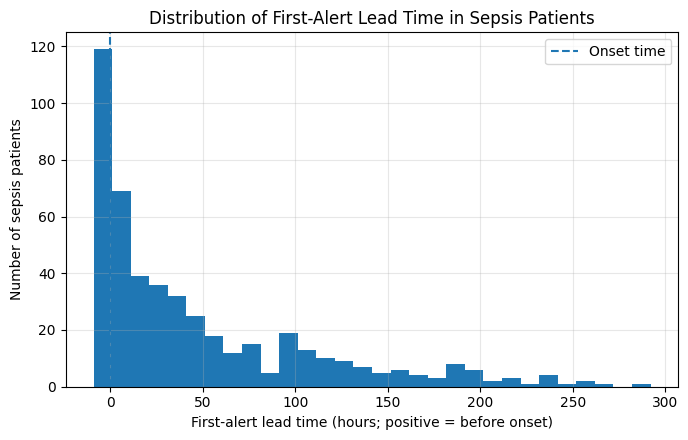

Saved: /kaggle/working/figure_patient_level_first_alert_lead_time.png


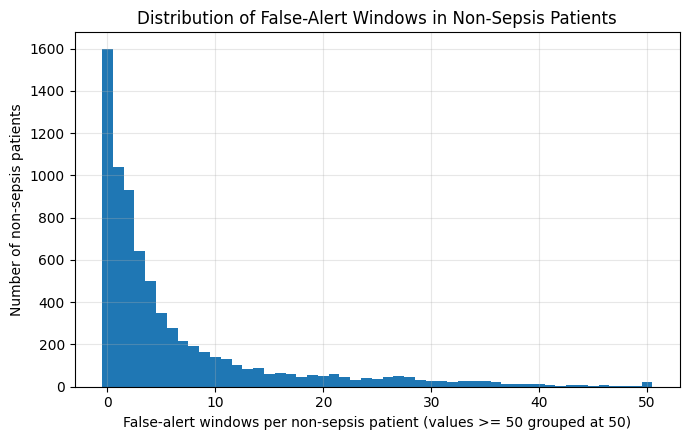

Saved: /kaggle/working/figure_nonsepsis_false_alert_windows.png


In [21]:
# Figure 1: first-alert lead time among alerted sepsis patients

lead_plot_df = sepsis_patients[
    (sepsis_patients["has_alert"] == 1) &
    (sepsis_patients["first_alert_lead_time"].notna())
].copy()

if len(lead_plot_df) > 0:
    lead_values = lead_plot_df["first_alert_lead_time"].to_numpy()

    fig, ax = plt.subplots(figsize=(7, 4.5))

    # Use integer-like bins when possible.
    min_lead = int(np.floor(np.nanmin(lead_values)))
    max_lead = int(np.ceil(np.nanmax(lead_values)))

    if max_lead - min_lead <= 60:
        bins = np.arange(min_lead - 0.5, max_lead + 1.5, 1)
    else:
        bins = 30

    ax.hist(lead_values, bins=bins)

    ax.axvline(
        0,
        linestyle="--",
        linewidth=1.5,
        label="Onset time"
    )

    ax.set_xlabel("First-alert lead time (hours; positive = before onset)")
    ax.set_ylabel("Number of sepsis patients")
    ax.set_title("Distribution of First-Alert Lead Time in Sepsis Patients")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")

    plt.tight_layout()

    fig_path = "/kaggle/working/figure_patient_level_first_alert_lead_time.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", fig_path)
else:
    print("No alerted sepsis patients available for lead-time plot.")

# Figure 2: false-alert windows per non-sepsis patient

fp_counts = nonsepsis_patients["n_alert_windows"].to_numpy()

fig, ax = plt.subplots(figsize=(7, 4.5))

max_count = int(np.nanmax(fp_counts)) if len(fp_counts) > 0 else 0

# To keep the plot readable, cap the displayed bins and report the cap in the x-label if needed.
display_cap = min(max_count, 50)
plot_values = np.minimum(fp_counts, display_cap)

bins = np.arange(-0.5, display_cap + 1.5, 1)

ax.hist(plot_values, bins=bins)

xlabel = "False-alert windows per non-sepsis patient"
if max_count > display_cap:
    xlabel += f" (values >= {display_cap} grouped at {display_cap})"

ax.set_xlabel(xlabel)
ax.set_ylabel("Number of non-sepsis patients")
ax.set_title("Distribution of False-Alert Windows in Non-Sepsis Patients")
ax.grid(True, alpha=0.3)

plt.tight_layout()

fig_path = "/kaggle/working/figure_nonsepsis_false_alert_windows.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

In [22]:
# Clinically relevant pre-onset alert horizons

horizon_rows = []

for h in [6, 12, 24, 48]:
    count = 0

    for _, row in sepsis_patients.iterrows():
        pid = row["patient_id"]
        onset = row["onset_hour"]

        g = df_patient_eval[
            (df_patient_eval["patient_id"] == pid) &
            (df_patient_eval["alert"] == 1)
        ]

        # alert within h hours before onset or at onset:
        # onset - h <= alert_hour <= onset
        has_alert_in_horizon = (
            (g["window_end_hour"] >= onset - h) &
            (g["window_end_hour"] <= onset)
        ).any()

        if has_alert_in_horizon:
            count += 1

    horizon_rows.append({
        "Horizon": f"Within {h}h before/onset",
        "Patients alerted": count,
        "Total sepsis patients": len(sepsis_patients),
        "Proportion": count / len(sepsis_patients)
    })

df_horizon_alerts = pd.DataFrame(horizon_rows)
display(df_horizon_alerts)

df_horizon_alerts.to_csv(
    "/kaggle/working/patient_level_alert_horizons.csv",
    index=False
)

,Horizon,Patients alerted,Total sepsis patients,Proportion
0,Within 6h before/onset,328,487,0.673511
1,Within 12h before/onset,343,487,0.704312
2,Within 24h before/onset,361,487,0.741273
3,Within 48h before/onset,370,487,0.759754


In [23]:
import pandas as pd
import numpy as np

# =========================
# 1. Load available patient-level data
# =========================

if "df_test_analysis" in globals():
    df_base = df_test_analysis.copy()
    print("Using df_test_analysis")

elif "df_patient_eval" in globals():
    df_base = df_patient_eval.copy()
    print("Using df_patient_eval")

elif "df_test_pred" in globals():
    df_base = df_test_pred.copy()
    print("Using df_test_pred")

else:
    # Nếu bạn đã chạy cell patient-level trước đó, file này đã được lưu trong /kaggle/working
    try:
        df_patient_alerts = pd.read_csv("/kaggle/working/patient_level_alerts.csv")
        print("Loaded /kaggle/working/patient_level_alerts.csv")

        total_patients = df_patient_alerts["patient_id"].nunique()
        sepsis_patients = int(df_patient_alerts["is_sepsis_patient"].sum())
        nonsepsis_patients = total_patients - sepsis_patients

        print("Total patients:", total_patients)
        print("Sepsis patients:", sepsis_patients)
        print("Non-sepsis patients:", nonsepsis_patients)
        print("Check:", sepsis_patients + nonsepsis_patients)

    except FileNotFoundError:
        print("No df_test_analysis in memory and no patient_level_alerts.csv found.")
        print("Run the patient-level analysis cell first, or load the prediction file again.")

Using df_test_analysis


In [24]:
import pandas as pd
import numpy as np

# =========================
# Load patient-level alert data
# =========================
try:
    df_patient_alerts
except NameError:
    df_patient_alerts = pd.read_csv("/kaggle/working/patient_level_alerts.csv")
    print("Loaded df_patient_alerts from /kaggle/working/patient_level_alerts.csv")

sepsis_patients = df_patient_alerts[
    df_patient_alerts["is_sepsis_patient"] == 1
].copy()

# =========================
# Define first-alert quality category
# =========================
def categorize_first_alert(row):
    if row["has_alert"] == 0:
        return "No alert during trajectory"
    
    lead = row["first_alert_lead_time"]
    
    if pd.isna(lead):
        return "No alert during trajectory"
    
    if lead < 0:
        return "Alert after onset only"
    elif lead == 0:
        return "Alert at onset"
    elif 0 < lead <= 6:
        return "Alert 1-6h before onset"
    elif 6 < lead <= 24:
        return "Alert >6-24h before onset"
    else:
        return "Alert >24h before onset"

sepsis_patients["first_alert_quality"] = sepsis_patients.apply(
    categorize_first_alert,
    axis=1
)

# =========================
# Summary table
# =========================
category_order = [
    "Alert >24h before onset",
    "Alert >6-24h before onset",
    "Alert 1-6h before onset",
    "Alert at onset",
    "Alert after onset only",
    "No alert during trajectory"
]

df_alert_quality = (
    sepsis_patients["first_alert_quality"]
    .value_counts()
    .reindex(category_order, fill_value=0)
    .reset_index()
)

df_alert_quality.columns = ["First-alert timing category", "Patients"]
df_alert_quality["Total sepsis patients"] = len(sepsis_patients)
df_alert_quality["Proportion"] = (
    df_alert_quality["Patients"] / len(sepsis_patients)
)

df_alert_quality["Proportion (%)"] = (
    df_alert_quality["Proportion"] * 100
).round(1)

display(df_alert_quality)

# Check sum
print("Total counted:", df_alert_quality["Patients"].sum())
print("Total sepsis patients:", len(sepsis_patients))

# Save
df_alert_quality.to_csv(
    "/kaggle/working/first_alert_quality_breakdown.csv",
    index=False
)

print("Saved: /kaggle/working/first_alert_quality_breakdown.csv")

,First-alert timing category,Patients,Total sepsis patients,Proportion,Proportion (%)
0,Alert >24h before onset,241,487,0.494867,49.5
1,Alert >6-24h before onset,79,487,0.162218,16.2
2,Alert 1-6h before onset,43,487,0.088296,8.8
3,Alert at onset,7,487,0.014374,1.4
4,Alert after onset only,105,487,0.215606,21.6
5,No alert during trajectory,12,487,0.024641,2.5


Total counted: 487
Total sepsis patients: 487
Saved: /kaggle/working/first_alert_quality_breakdown.csv


In [25]:
import pandas as pd
import numpy as np

# =========================
# Load data if needed
# =========================
try:
    df_alert_episodes
except NameError:
    df_alert_episodes = pd.read_csv("/kaggle/working/patient_alert_episodes.csv")
    print("Loaded df_alert_episodes from /kaggle/working/patient_alert_episodes.csv")

try:
    df_patient_alerts
except NameError:
    df_patient_alerts = pd.read_csv("/kaggle/working/patient_level_alerts.csv")
    print("Loaded df_patient_alerts from /kaggle/working/patient_level_alerts.csv")

nonsepsis_patients = df_patient_alerts[
    df_patient_alerts["is_sepsis_patient"] == 0
].copy()

nonsepsis_episodes = df_alert_episodes[
    df_alert_episodes["is_sepsis_patient"] == 0
].copy()

episode_lengths = nonsepsis_episodes["episode_length_windows"]

# =========================
# Episode-level summary
# =========================
summary_rows = []

summary_rows.append({
    "Metric": "Number of non-sepsis patients",
    "Value": len(nonsepsis_patients)
})

summary_rows.append({
    "Metric": "Number of false-alert episodes",
    "Value": len(nonsepsis_episodes)
})

summary_rows.append({
    "Metric": "Mean false-alert episode length",
    "Value": round(episode_lengths.mean(), 2)
})

summary_rows.append({
    "Metric": "Median false-alert episode length",
    "Value": round(episode_lengths.median(), 1)
})

summary_rows.append({
    "Metric": "75th percentile false-alert episode length",
    "Value": round(episode_lengths.quantile(0.75), 1)
})

summary_rows.append({
    "Metric": "90th percentile false-alert episode length",
    "Value": round(episode_lengths.quantile(0.90), 1)
})

summary_rows.append({
    "Metric": "95th percentile false-alert episode length",
    "Value": round(episode_lengths.quantile(0.95), 1)
})

summary_rows.append({
    "Metric": "Maximum false-alert episode length",
    "Value": int(episode_lengths.max())
})

# =========================
# Patient-level sustained episode thresholds
# =========================
max_episode_per_nonsepsis_patient = (
    nonsepsis_episodes
    .groupby("patient_id")["episode_length_windows"]
    .max()
    .reset_index()
    .rename(columns={"episode_length_windows": "max_false_alert_episode_length"})
)

nonsepsis_patients_episode = nonsepsis_patients.merge(
    max_episode_per_nonsepsis_patient,
    on="patient_id",
    how="left"
)

nonsepsis_patients_episode["max_false_alert_episode_length"] = (
    nonsepsis_patients_episode["max_false_alert_episode_length"].fillna(0)
)

for threshold in [3, 6, 12, 24]:
    n_patients = int(
        (nonsepsis_patients_episode["max_false_alert_episode_length"] >= threshold).sum()
    )
    
    summary_rows.append({
        "Metric": f"Non-sepsis patients with at least one false-alert episode >= {threshold} windows",
        "Value": f"{n_patients}/{len(nonsepsis_patients)} ({n_patients / len(nonsepsis_patients) * 100:.1f}%)"
    })

df_false_episode_summary = pd.DataFrame(summary_rows)

display(df_false_episode_summary)

# Save
df_false_episode_summary.to_csv(
    "/kaggle/working/false_alert_episode_summary.csv",
    index=False
)

nonsepsis_patients_episode.to_csv(
    "/kaggle/working/nonsepsis_patient_episode_summary.csv",
    index=False
)

print("Saved: /kaggle/working/false_alert_episode_summary.csv")
print("Saved: /kaggle/working/nonsepsis_patient_episode_summary.csv")

,Metric,Value
0,Number of non-sepsis patients,7477
1,Number of false-alert episodes,9254
2,Mean false-alert episode length,5.36
3,Median false-alert episode length,3.0
4,75th percentile false-alert episode length,6.0
5,90th percentile false-alert episode length,11.0
6,95th percentile false-alert episode length,17.0
7,Maximum false-alert episode length,273
8,Non-sepsis patients with at least one false-al...,3802/7477 (50.8%)
9,Non-sepsis patients with at least one false-al...,2102/7477 (28.1%)


Saved: /kaggle/working/false_alert_episode_summary.csv
Saved: /kaggle/working/nonsepsis_patient_episode_summary.csv
